What is the average delay time of all routes across the entire city?

What is the average delay time of the target bus routes (22, 29, 15, 45, 28, 44, 42, 17, 23, 31, 26, 111, 24, 33, 14 - from Livable Streets report)?


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from bus_delay_time_analysis.routes_preprocessing import *

In [3]:
# Last file of 2024 used for testing and analytics
filename = "./datasets/MBTA_Bus_Arrival_Departure_Times_2024/MBTA-Bus-Arrival-Departure-Times_2024-12.csv"

In [4]:
df = pd.read_csv(filename, low_memory=False)

In [5]:
avg_positive_delay_per_route = preprocess_routes(df)

c:\Users\Michael\Desktop\BU\2025-Spring\CS 506\Final_Project\MBTA-bus-inequity-analysis\bus_delay_time_analysis\routes_preprocessing.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  routes_df['time_difference'] = pd.to_datetime(routes_df['actual']) - pd.to_datetime(routes_df['scheduled'])
c:\Users\Michael\Desktop\BU\2025-Spring\CS 506\Final_Project\MBTA-bus-inequity-analysis\bus_delay_time_analysis\routes_preprocessing.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  routes_df['delay_seconds'] = route

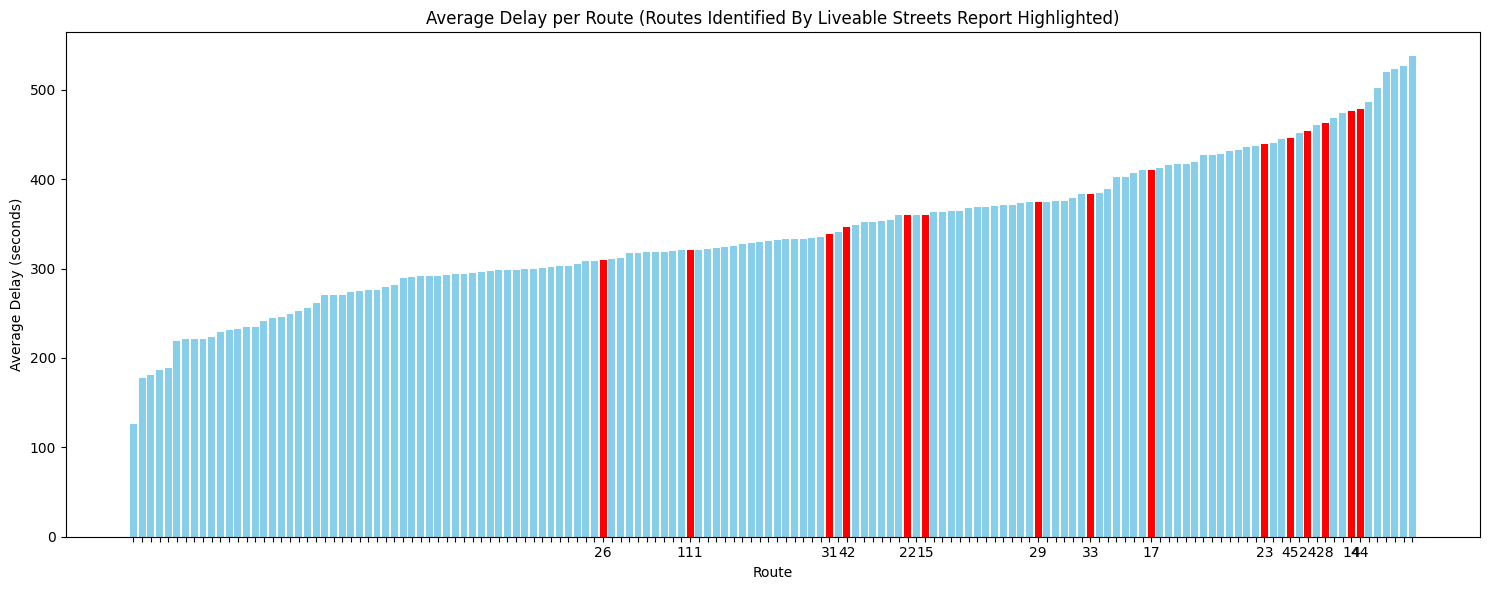

In [6]:
target_routes = {"22", "29", "15", "45", "28", "44", "42", "17", "23", "31", "26", "111", "24", "33", "14"}


avg_positive_delay_per_route = avg_positive_delay_per_route.sort_values(by='delay_seconds', ascending=True)



colors = ['red' if route in target_routes else 'skyblue' for route in avg_positive_delay_per_route['route_id']]

tick_labels = [route if route in target_routes else '' for route in avg_positive_delay_per_route['route_id']]


plt.figure(figsize=(15, 6))
plt.bar(avg_positive_delay_per_route['route_id'], avg_positive_delay_per_route['delay_seconds'], color=colors)
plt.xlabel('Route')
plt.ylabel('Average Delay (seconds)')
plt.title('Average Delay per Route (Routes Identified By Liveable Streets Report Highlighted)')
plt.xticks(range(len(avg_positive_delay_per_route['route_id'])), tick_labels)
plt.tight_layout()
plt.show()

